In [1]:

from datasets import Dataset, load_from_disk, DatasetDict, Features, Sequence, Value
import pandas as pd
import json

/data/ephemeral/home/.py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Dataset

In [2]:

# Train, Validation
dataset = load_from_disk("../data/train_dataset/")

train = dataset['train']
val = dataset['validation']

In [3]:

# Wiki (Retrieval Data)
with open("../data/wikipedia_documents.json", 'r', encoding='utf-8') as f:
    wiki_data = json.load(f)

wiki_data_list = list(wiki_data.values())
wiki_dataset = Dataset.from_list(wiki_data_list)


In [ ]:

# Test
test_dataset = load_from_disk("../data/test_dataset/")
test = test_dataset['validation']

## 2. Datasets -> DataFrame

In [5]:

# Dataset -> DataFrame
train_df = pd.DataFrame(train) #3952
val_df = pd.DataFrame(val) #240
wiki_df = pd.DataFrame(wiki_dataset) #60613
test_df = pd.DataFrame(test) #600


In [45]:
wiki_df = wiki_df.drop_duplicates(subset=['text'])
len(wiki_df) #56737

56737

In [69]:
pred_path = '../outputs/train_result/predictions_submit.csv'
train_pred = pd.read_csv(pred_path, sep='\t', header=None, names=['ID', 'Predict'])
train_pred.head()

,ID,Predict
0,mrc-0-003264,한보철강
1,mrc-0-004762,1871년
2,mrc-1-001810,나뭇잎
3,mrc-1-000219,금대야
4,mrc-1-000285,위계 서열적 관계에서 벗어난 수평적 관계


In [129]:
train_answers =val_df[['id', 'question', 'answers', 'document_id']]
train_answers.head()

,id,question,answers,document_id
0,mrc-0-003264,처음으로 부실 경영인에 대한 보상 선고를 받은 회사는?,"{'answer_start': [284], 'text': ['한보철강']}",9027
1,mrc-0-004762,스카버러 남쪽과 코보콘그 마을의 철도 노선이 처음 연장된 연도는?,"{'answer_start': [146], 'text': ['1871년']}",51765
2,mrc-1-001810,촌락에서 운영 위원 후보자 이름을 쓰기위해 사용된 것은?,"{'answer_start': [517], 'text': ['나뭇잎']}",15694
3,mrc-1-000219,로타이르가 백조를 구하기 위해 사용한 것은?,"{'answer_start': [1109], 'text': ['금대야']}",59536
4,mrc-1-000285,의견을 자유롭게 나누는 것은 조직 내 어떤 관계에서 가능한가?,"{'answer_start': [386], 'text': ['수평적 관계']}",32991


In [130]:
train_answers['answers'] = train_answers['answers'].apply(lambda x: ''.join(x['text']))

/tmp/ipykernel_931260/1559022864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_answers['answers'] = train_answers['answers'].apply(lambda x: ''.join(x['text']))


In [131]:
train_answers.head()

,id,question,answers,document_id
0,mrc-0-003264,처음으로 부실 경영인에 대한 보상 선고를 받은 회사는?,한보철강,9027
1,mrc-0-004762,스카버러 남쪽과 코보콘그 마을의 철도 노선이 처음 연장된 연도는?,1871년,51765
2,mrc-1-001810,촌락에서 운영 위원 후보자 이름을 쓰기위해 사용된 것은?,나뭇잎,15694
3,mrc-1-000219,로타이르가 백조를 구하기 위해 사용한 것은?,금대야,59536
4,mrc-1-000285,의견을 자유롭게 나누는 것은 조직 내 어떤 관계에서 가능한가?,수평적 관계,32991


In [132]:
train_answers['ID'] = train_answers['id']
del train_answers['id']

/tmp/ipykernel_931260/1583214133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_answers['ID'] = train_answers['id']


In [133]:
train_answers.head()

,question,answers,document_id,ID
0,처음으로 부실 경영인에 대한 보상 선고를 받은 회사는?,한보철강,9027,mrc-0-003264
1,스카버러 남쪽과 코보콘그 마을의 철도 노선이 처음 연장된 연도는?,1871년,51765,mrc-0-004762
2,촌락에서 운영 위원 후보자 이름을 쓰기위해 사용된 것은?,나뭇잎,15694,mrc-1-001810
3,로타이르가 백조를 구하기 위해 사용한 것은?,금대야,59536,mrc-1-000219
4,의견을 자유롭게 나누는 것은 조직 내 어떤 관계에서 가능한가?,수평적 관계,32991,mrc-1-000285


In [134]:
print(len(train_answers))
print(len(train_pred))

240
240


In [135]:
train_ans_pred = pd.merge(train_answers, train_pred, on='ID', how='left')
print(len(train_ans_pred))

240


In [136]:
train_ans_pred.head()

,question,answers,document_id,ID,Predict
0,처음으로 부실 경영인에 대한 보상 선고를 받은 회사는?,한보철강,9027,mrc-0-003264,한보철강
1,스카버러 남쪽과 코보콘그 마을의 철도 노선이 처음 연장된 연도는?,1871년,51765,mrc-0-004762,1871년
2,촌락에서 운영 위원 후보자 이름을 쓰기위해 사용된 것은?,나뭇잎,15694,mrc-1-001810,나뭇잎
3,로타이르가 백조를 구하기 위해 사용한 것은?,금대야,59536,mrc-1-000219,금대야
4,의견을 자유롭게 나누는 것은 조직 내 어떤 관계에서 가능한가?,수평적 관계,32991,mrc-1-000285,위계 서열적 관계에서 벗어난 수평적 관계


In [137]:
train_ans_pred['Question'] = train_ans_pred['question']
del train_ans_pred['question']

train_ans_pred['Answers'] = train_ans_pred['answers']
del train_ans_pred['answers']

In [138]:

train_ans_pred = train_ans_pred[['ID', 'Question', 'Answers', 'Predict', 'document_id']]
train_ans_pred.head()

,ID,Question,Answers,Predict,document_id
0,mrc-0-003264,처음으로 부실 경영인에 대한 보상 선고를 받은 회사는?,한보철강,한보철강,9027
1,mrc-0-004762,스카버러 남쪽과 코보콘그 마을의 철도 노선이 처음 연장된 연도는?,1871년,1871년,51765
2,mrc-1-001810,촌락에서 운영 위원 후보자 이름을 쓰기위해 사용된 것은?,나뭇잎,나뭇잎,15694
3,mrc-1-000219,로타이르가 백조를 구하기 위해 사용한 것은?,금대야,금대야,59536
4,mrc-1-000285,의견을 자유롭게 나누는 것은 조직 내 어떤 관계에서 가능한가?,수평적 관계,위계 서열적 관계에서 벗어난 수평적 관계,32991


In [142]:
train_ans_pred_wiki = pd.merge(train_ans_pred, wiki_df, on='document_id', how='left')
print(len(train_ans_pred_wiki))
train_ans_pred_wiki.head()

240


,ID,Question,Answers,Predict,document_id,text,corpus_source,url,domain,title,author,html
0,mrc-0-003264,처음으로 부실 경영인에 대한 보상 선고를 받은 회사는?,한보철강,한보철강,9027,"순천여자고등학교 졸업, 1973년 이화여자대학교를 졸업하고 1975년 제17회 사법...",위키피디아,None,None,전효숙,None,None
1,mrc-0-004762,스카버러 남쪽과 코보콘그 마을의 철도 노선이 처음 연장된 연도는?,1871년,1871년,51765,요크 카운티 동쪽에 처음으로 여객 열차 운행이 시작한 시점은 1868년 토론토 & ...,위키피디아,None,None,스토우빌선,None,None
2,mrc-1-001810,촌락에서 운영 위원 후보자 이름을 쓰기위해 사용된 것은?,나뭇잎,나뭇잎,15694,"촐라 정부\n 촐라의 정부 체제는 전제군주제였으며,2001 촐라의 군주는 절대적인 ...",위키피디아,None,None,촐라,None,None
3,mrc-1-000219,로타이르가 백조를 구하기 위해 사용한 것은?,금대야,금대야,59536,프랑스의 십자군 무훈시는 1099년 예루살렘 왕국의 통치자가 된 고드프루아 드 부용...,위키피디아,None,None,백조 기사,None,None
4,mrc-1-000285,의견을 자유롭게 나누는 것은 조직 내 어떤 관계에서 가능한가?,수평적 관계,위계 서열적 관계에서 벗어난 수평적 관계,32991,탈관료제화는 현대사회에서 관료제 성격이 약화되는 현상이다. 현대사회에서 관료제는 약...,위키피디아,None,None,탈관료제화,None,None


In [143]:
del train_ans_pred_wiki['corpus_source']
del train_ans_pred_wiki['url']
del train_ans_pred_wiki['domain']
del train_ans_pred_wiki['title']
del train_ans_pred_wiki['author']
del train_ans_pred_wiki['html']

train_ans_pred_wiki.head()


,ID,Question,Answers,Predict,document_id,text
0,mrc-0-003264,처음으로 부실 경영인에 대한 보상 선고를 받은 회사는?,한보철강,한보철강,9027,"순천여자고등학교 졸업, 1973년 이화여자대학교를 졸업하고 1975년 제17회 사법..."
1,mrc-0-004762,스카버러 남쪽과 코보콘그 마을의 철도 노선이 처음 연장된 연도는?,1871년,1871년,51765,요크 카운티 동쪽에 처음으로 여객 열차 운행이 시작한 시점은 1868년 토론토 & ...
2,mrc-1-001810,촌락에서 운영 위원 후보자 이름을 쓰기위해 사용된 것은?,나뭇잎,나뭇잎,15694,"촐라 정부\n 촐라의 정부 체제는 전제군주제였으며,2001 촐라의 군주는 절대적인 ..."
3,mrc-1-000219,로타이르가 백조를 구하기 위해 사용한 것은?,금대야,금대야,59536,프랑스의 십자군 무훈시는 1099년 예루살렘 왕국의 통치자가 된 고드프루아 드 부용...
4,mrc-1-000285,의견을 자유롭게 나누는 것은 조직 내 어떤 관계에서 가능한가?,수평적 관계,위계 서열적 관계에서 벗어난 수평적 관계,32991,탈관료제화는 현대사회에서 관료제 성격이 약화되는 현상이다. 현대사회에서 관료제는 약...


In [144]:
train_ans_pred.to_csv('train_ans_pred_wiki.csv')

In [ ]:
correct = train_ans_pred_wiki[train_ans_pred_wiki['Predict']==train_ans_pred_wiki['Answers']] #157
wrong = train_ans_pred_wiki[train_ans_pred_wiki['Predict']!=train_ans_pred_wiki['Answers']] #83

157
83



[Question] 길이 통계
  - Correct 평균: 30.38 (최대: 59)
  - Wrong   평균: 26.95 (최대: 52)

[Answers] 길이 통계
  - Correct 평균: 6.05 (최대: 34)
  - Wrong   평균: 8.54 (최대: 64)


/tmp/ipykernel_931260/2449326520.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Length', data=temp_df, ax=axes[i][1], palette={'Correct': 'blue', 'Wrong': 'red'})
/tmp/ipykernel_931260/2449326520.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Length', data=temp_df, ax=axes[i][1], palette={'Correct': 'blue', 'Wrong': 'red'})



[Predict] 길이 통계
  - Correct 평균: 6.05 (최대: 34)
  - Wrong   평균: 8.59 (최대: 62)

[text] 길이 통계
  - Correct 평균: 891.52 (최대: 2064)
  - Wrong   평균: 955.81 (최대: 2043)


/tmp/ipykernel_931260/2449326520.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Length', data=temp_df, ax=axes[i][1], palette={'Correct': 'blue', 'Wrong': 'red'})
/tmp/ipykernel_931260/2449326520.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Length', data=temp_df, ax=axes[i][1], palette={'Correct': 'blue', 'Wrong': 'red'})


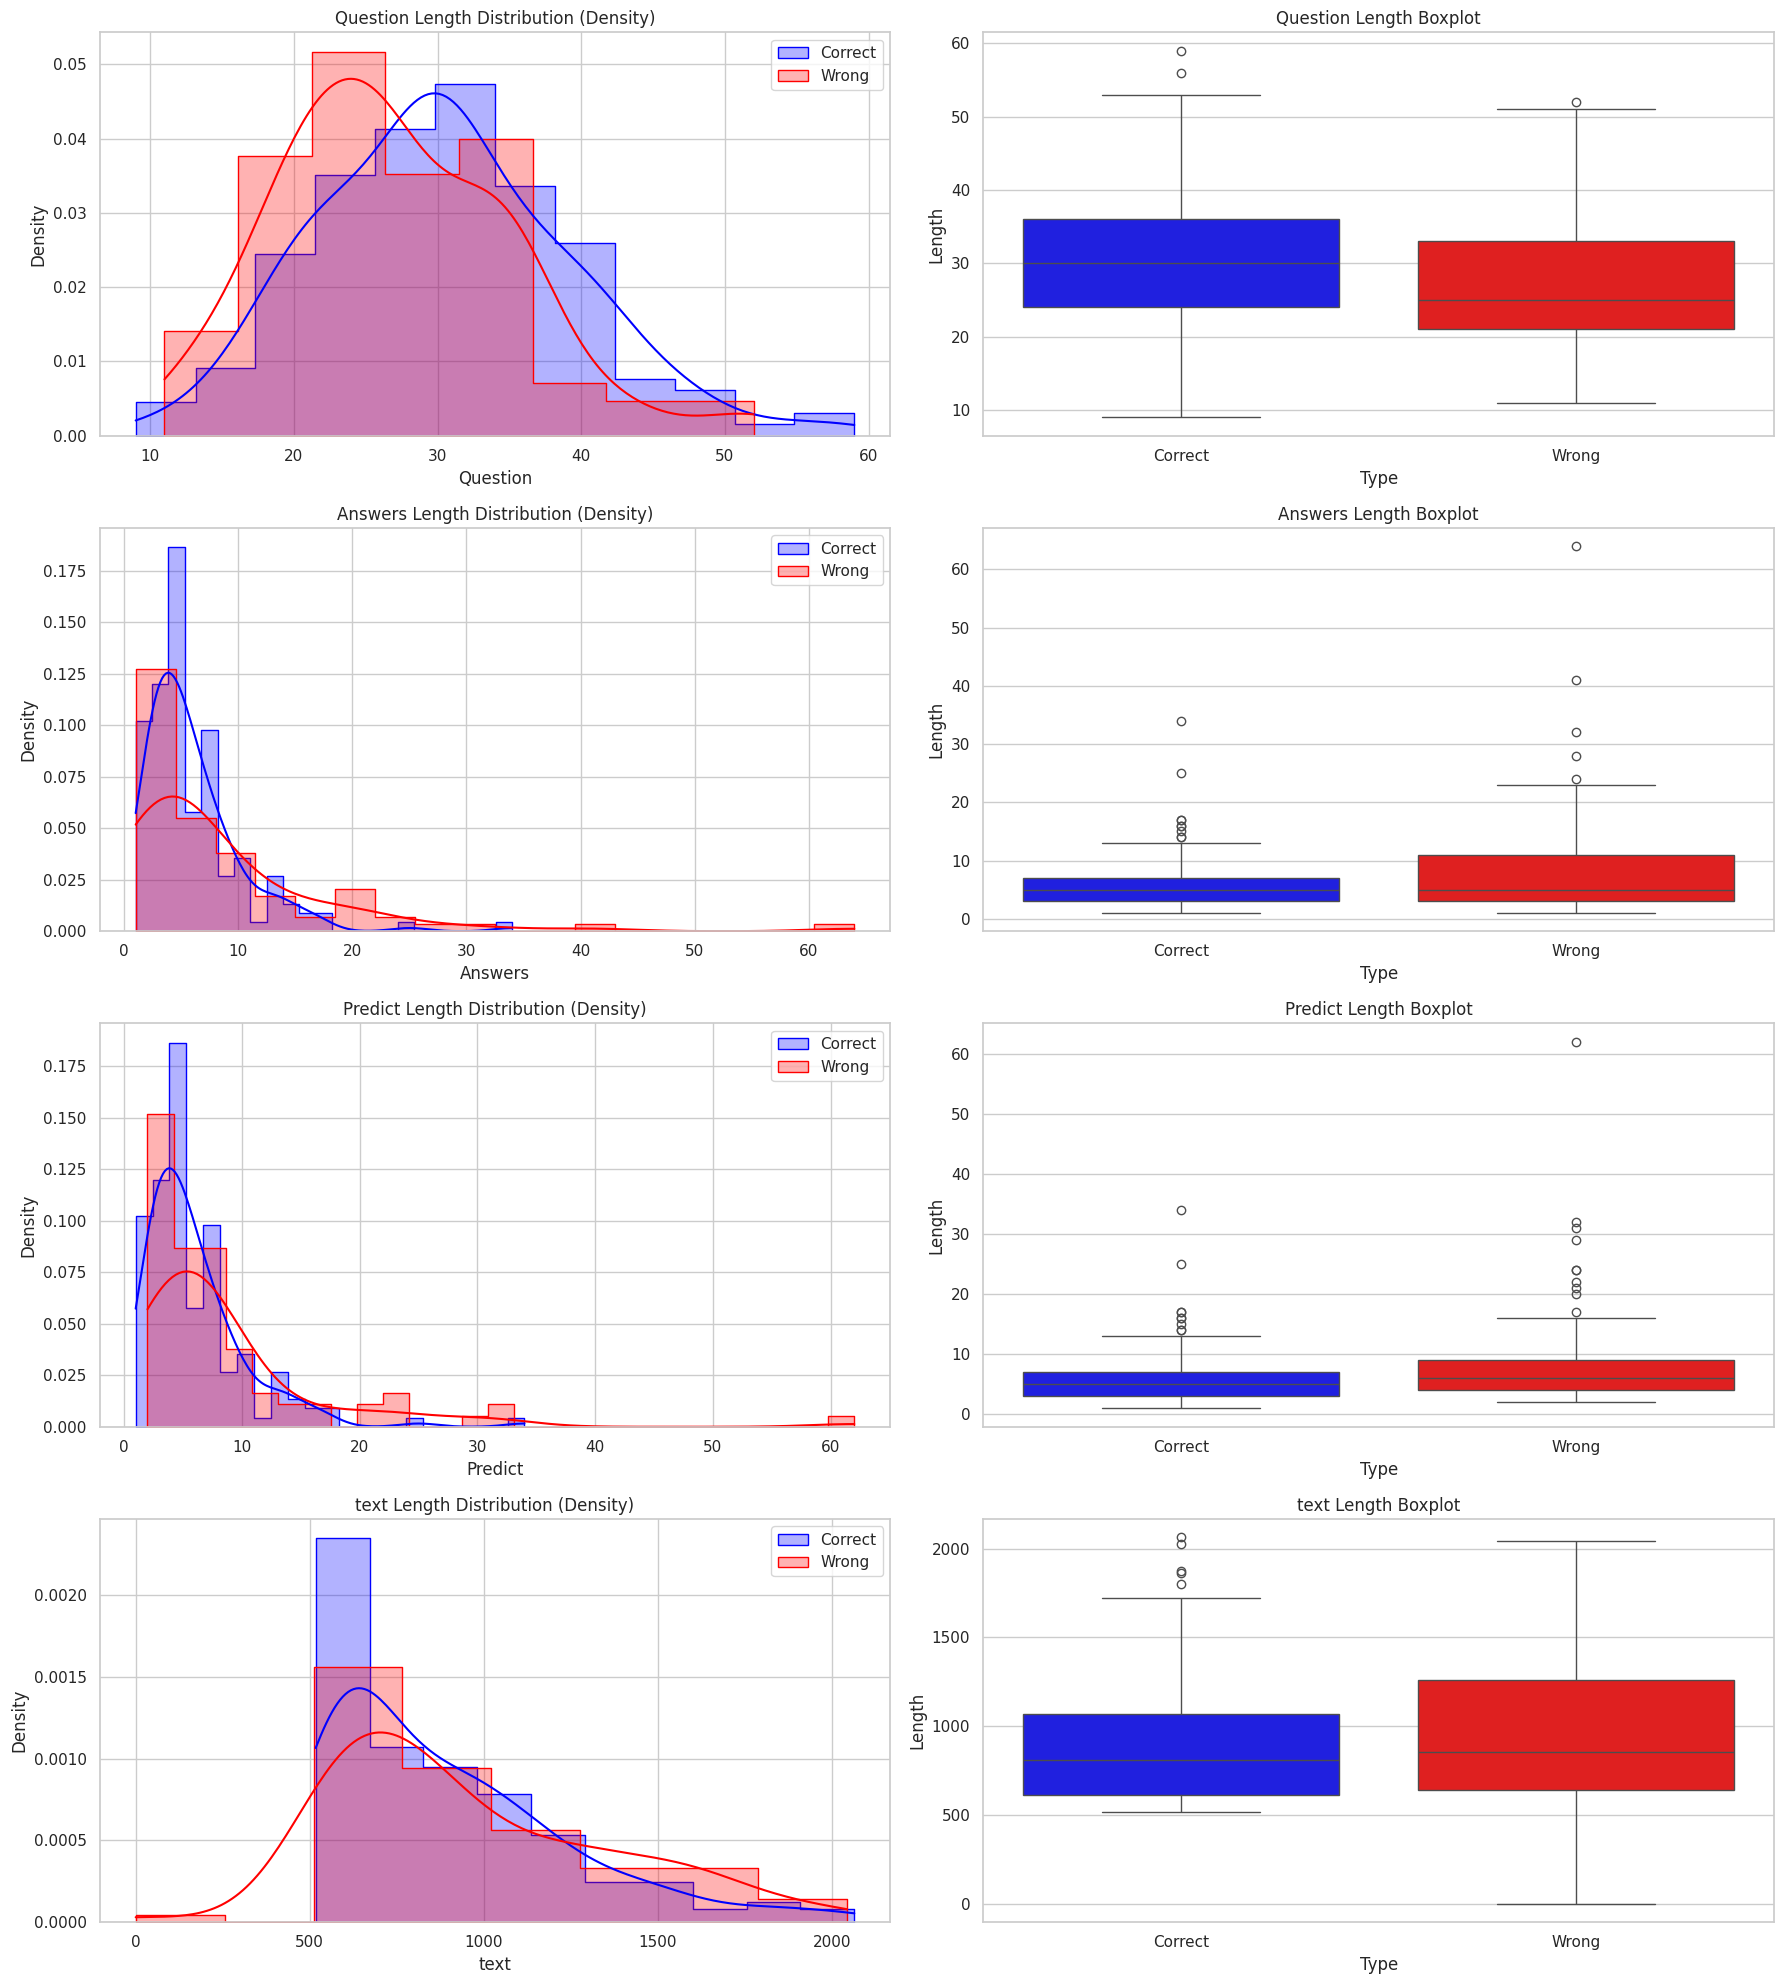

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 분석할 컬럼 리스트
target_columns = ['Question', 'Answers', 'Predict', 'text'] # 대소문자 확인 필요 (df.columns로 확인)

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

def get_text_length(x):
    """
    데이터 타입에 따라 길이를 반환하는 함수
    - 리스트(Answers 등): 문자열로 변환 후 길이 측정 (또는 원소 개수 len(x)로 변경 가능)
    - 문자열: 바로 길이 측정
    - 기타(NaN): 0 반환
    """
    if isinstance(x, list):
        return len(str(x)) # 리스트 자체의 문자열 길이
    elif pd.isna(x):
        return 0
    else:
        return len(str(x))

# 각 컬럼별로 순회하며 그래프 그리기
fig, axes = plt.subplots(len(target_columns), 2, figsize=(18, 5 * len(target_columns)))

for i, col in enumerate(target_columns):
    # 컬럼이 있는지 확인
    if col not in correct.columns or col not in wrong.columns:
        print(f"⚠️ 컬럼 '{col}'이(가) 데이터프레임에 없습니다. 스킵합니다.")
        continue
    
    # 1. 길이 계산
    # correct/wrong 데이터에서 각각 길이를 추출
    len_correct = correct[col].apply(get_text_length)
    len_wrong = wrong[col].apply(get_text_length)
    
    # 2. 통계치 출력
    print(f"\n[{col}] 길이 통계")
    print(f"  - Correct 평균: {len_correct.mean():.2f} (최대: {len_correct.max()})")
    print(f"  - Wrong   평균: {len_wrong.mean():.2f} (최대: {len_wrong.max()})")
    
    # 3. 히스토그램 (분포 비교) - 왼쪽 그래프
    sns.histplot(len_correct, color='blue', label='Correct', kde=True, stat="density", element="step", alpha=0.3, ax=axes[i][0])
    sns.histplot(len_wrong, color='red', label='Wrong', kde=True, stat="density", element="step", alpha=0.3, ax=axes[i][0])
    axes[i][0].set_title(f'{col} Length Distribution (Density)')
    axes[i][0].legend()
    
    # 4. 박스플롯 (이상치 및 범위 비교) - 오른쪽 그래프
    # 시각화를 위해 임시 데이터프레임 생성
    temp_df = pd.DataFrame({
        'Length': pd.concat([len_correct, len_wrong]),
        'Type': ['Correct'] * len(len_correct) + ['Wrong'] * len(len_wrong)
    })
    sns.boxplot(x='Type', y='Length', data=temp_df, ax=axes[i][1], palette={'Correct': 'blue', 'Wrong': 'red'})
    axes[i][1].set_title(f'{col} Length Boxplot')

plt.tight_layout()
plt.show()